0. Importing Libraries

In [36]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Class Balancing Tool (SMOTE)
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Confusion Matrix
from sklearn.metrics import confusion_matrix

print("All libraries imported successfully! Ready for data load.")

All libraries imported successfully! Ready for data load.


Loading The CSV File

In [37]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

1. EDA

In [38]:
if 'tenure' in df.columns:                          #change tenure to Tenure
    df = df.rename(columns={'tenure': 'Tenure'})  

sns.set_theme(style="whitegrid")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


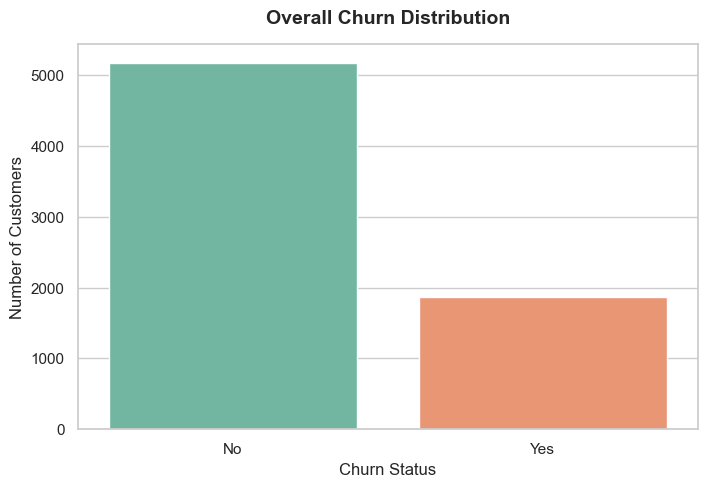

In [39]:

plt.figure(figsize=(8, 5))              #creating graph space

churn_counts = df['Churn'].value_counts().sort_values(ascending=False)  #calculate churn counts and keep higher one first

sns.barplot(x=churn_counts.index, y=churn_counts.values, palette='Set2', order=churn_counts.index)      #making bar chart

plt.title('Overall Churn Distribution', fontsize=14, fontweight='bold', pad=15)  #add title
plt.xlabel('Churn Status', fontsize=12)         #label
plt.ylabel('Number of Customers', fontsize=12)      #label


plt.show()  #print

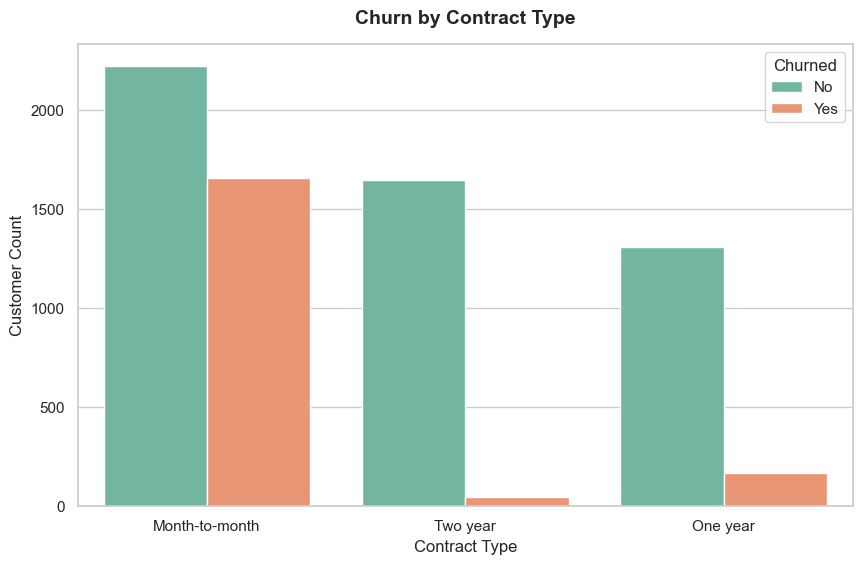

In [40]:
plt.figure(figsize=(10, 6))

contract_order = df['Contract'].value_counts().index        #ordering contracts - most used one first

sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2', order=contract_order)     #create multiple bar graph

plt.title('Churn by Contract Type', fontsize=14, fontweight='bold', pad=15)    #title
plt.xlabel('Contract Type', fontsize=12)    #label
plt.ylabel('Customer Count', fontsize=12)   #label
plt.legend(title='Churned')        #key

plt.show()

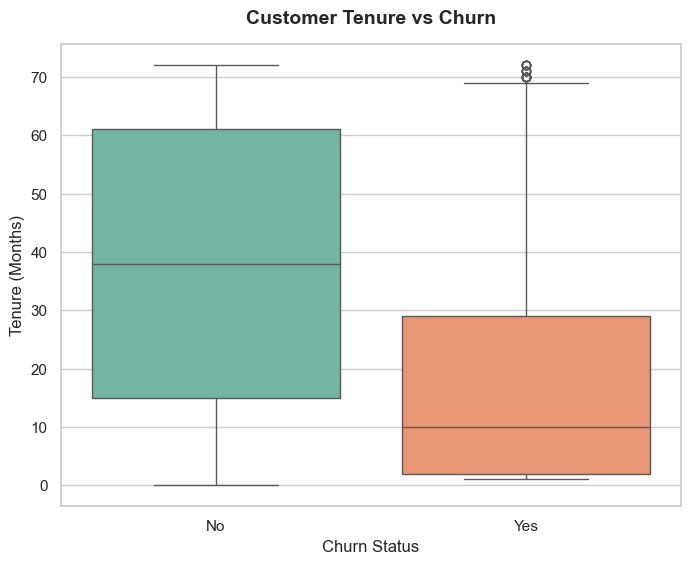

In [41]:
plt.figure(figsize=(8, 6))

sns.boxplot(data=df, x='Churn', y='Tenure', palette='Set2', order=['No', 'Yes'])     #create box and whisker plot

plt.title('Customer Tenure vs Churn', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Churn Status', fontsize=12)
plt.ylabel('Tenure (Months)', fontsize=12)

plt.show()

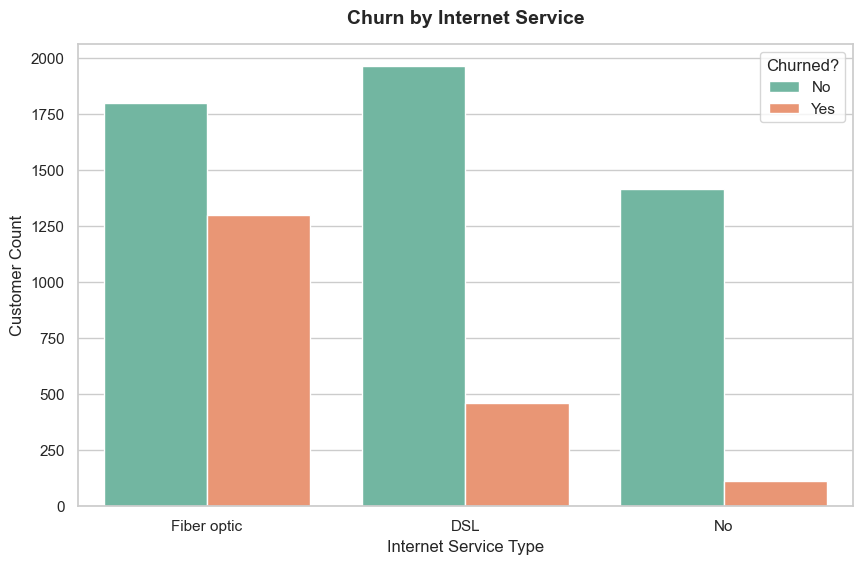

In [42]:
plt.figure(figsize=(10, 6))

internet_order = df['InternetService'].value_counts().index       

sns.countplot(data=df, x='InternetService', hue='Churn', palette='Set2', order=internet_order)      #create multiple bar graph

plt.title('Churn by Internet Service', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Internet Service Type', fontsize=12)
plt.ylabel('Customer Count', fontsize=12)
plt.legend(title='Churned?')

plt.show()

2. Data Cleaning and Feature Engineering

In [ ]:
df.drop(columns=['customerID'], inplace=True)

# ========= Convert TotalCharges from text objects to mathematical floating decimals =========

df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# ========= Map target churn strings to mathematical binary integers =========
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# ========= Split features into descriptor matrix (X) and target array (y) =========
X = df.drop(columns=['Churn'])
y = df['Churn']

# ========= Apply One-Hot Encoding to expand string categories into columns of 1s and 0s =========
X_encoded = pd.get_dummies(X, drop_first=True, dtype=int)

display(X_encoded.head(3))

,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1


3. Data Partitioning & Balancing (SMOTE)

In [ ]:
# ========= Drop any rows containing missing values generated during encoding to prevent errors =========
X_encoded = X_encoded.dropna()
y = y[X_encoded.index]  # Align the target vector so it matches the rows left in X

# ========= Split data 80/20 for training and testing respectively  =========
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.20, random_state=42, stratify=y)

# ========= Normalize numerical ranges =========
scaler = StandardScaler()

# ========= Identify your continuous numerical columns that need scaling =========
num_cols = ['Tenure', 'MonthlyCharges', 'TotalCharges']

# ========= Fit the scaler on the training features and transform both splits =========
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# ========= Initialize SMOTE to balance the training data classes =========
smote = SMOTE(random_state=42)

# ========= Apply SMOTE exclusively to the training part =========
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE balancing:  Stay (0) = {list(y_train).count(0)}, Churn (1) = {list(y_train).count(1)}")
print(f"After SMOTE balancing:  Stay (0) = {list(y_train_res).count(0)}, Churn (1) = {list(y_train_res).count(1)}")
print(f"Testing Data:  Stay (0) = {list(y_test).count(0)}, Churn (1) = {list(y_test).count(1)}")

Before SMOTE balancing:  Stay (0) = 4130, Churn (1) = 1495
After SMOTE balancing:  Stay (0) = 4130, Churn (1) = 4130
Testing Data:  Stay (0) = 1033, Churn (1) = 374


4. Comparative Model Evaluation

In [ ]:
# Initialise the three models

log_reg = LogisticRegression(max_iter=1000, random_state=42)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Training the Logistic Regression model

log_reg.fit(X_train_res, y_train_res)
y_pred_log = log_reg.predict(X_test)
y_prob_log = log_reg.predict_proba(X_test)[:, 1]

# Training the Random Forest ensemble model

rf_clf.fit(X_train_res, y_train_res)
y_pred_rf = rf_clf.predict(X_test)
y_prob_rf = rf_clf.predict_proba(X_test)[:, 1]

# Training the advanced XGBoost model

xgb_clf.fit(X_train_res, y_train_res)
y_pred_xgb = xgb_clf.predict(X_test)
y_prob_xgb = xgb_clf.predict_proba(X_test)[:, 1]

print("All models finished training")

All models finished training


5. Confusion Matrix

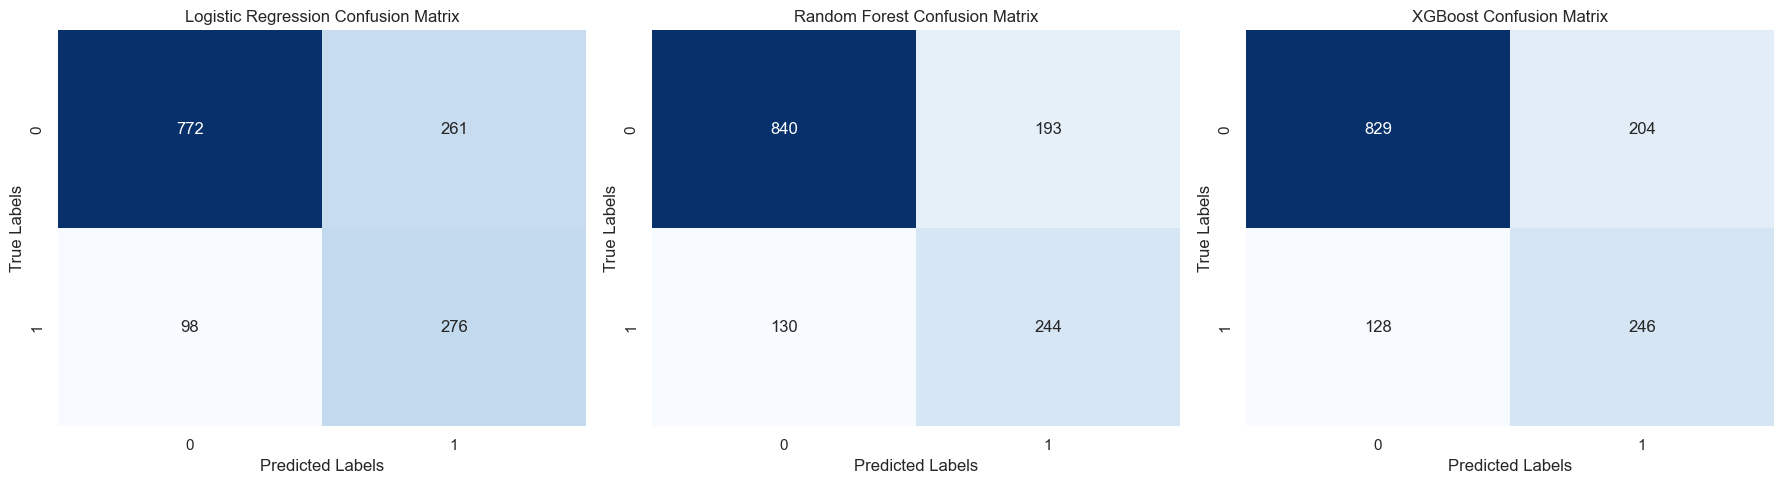

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Dictionary mapping to help iterate through the model data easily

models_data = {
    "Logistic Regression": (y_test, y_pred_log, axes[0]),
    "Random Forest": (y_test, y_pred_rf, axes[1]),
    "XGBoost": (y_test, y_pred_xgb, axes[2])
}

# Loop through our dictionary to generate the three Confusion Matrixes

for name, (true_labels, pred_labels, ax) in models_data.items():
    cm = confusion_matrix(true_labels, pred_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel("Predicted Labels")
    ax.set_ylabel("True Labels")

plt.tight_layout()
plt.show()